In [2]:
import pandas as pd 
import torch
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

In [3]:
data = pd.read_csv("train.csv")
X = torch.tensor(data.iloc[:, 1:].values, dtype=torch.float32)  # pixel values
y = torch.tensor(data.iloc[:, 0].values, dtype=torch.long)      # labels
count = len(X)
# print(count)
# Calculate mean and std from the training data
mean = torch.mean(X)
std = torch.std(X)

# Normalize to zero mean, unit variance
X = (X - mean) / std
X = X.view(count, 1, 28, 28)
dataset = TensorDataset(X, y)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

In [4]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 20, 5)
        self.conv2 = nn.Conv2d(20, 20, 5)
        self.out = nn.Linear(8000, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = x.view(x.size(0), -1)
        return self.out(x)

In [16]:
model = Model()
losswatch = []
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 2. Loop for 10 epochs
for epoch in range(10):
    epoch_loss = 0.0 # Keep track of the loss for this epoch
    
    # Loop through the entire dataset in batches
    for X_batch, y_batch in dataloader:
        
        # Step A: Clear old gradients
        optimizer.zero_grad()
        
        # Step B: Forward pass (make predictions)
        output = model(X_batch)
        
        # Step C: Calculate loss
        loss = F.cross_entropy(output, y_batch)
        
        # Step D: Backward propagation (calculate how to fix the errors)
        loss.backward()
        
        # Step E: Update the model's weights
        optimizer.step()
        
        # Add up the loss so we can average it later
        epoch_loss += loss.item()
            
    # Print the average loss just ONCE per epoch, not every batch
    average_loss = epoch_loss / len(dataloader)
    losswatch.append(average_loss)
    print(f"Epoch {epoch+1}/10 | Average Loss: {average_loss:.4f}")

    torch.save({
    'epoch': epoch,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': average_loss
    }, "checkpoint.pth")



Epoch 1/10 | Average Loss: 0.1567
Epoch 2/10 | Average Loss: 0.0537
Epoch 3/10 | Average Loss: 0.0373
Epoch 4/10 | Average Loss: 0.0274
Epoch 5/10 | Average Loss: 0.0189
Epoch 6/10 | Average Loss: 0.0147
Epoch 7/10 | Average Loss: 0.0134
Epoch 8/10 | Average Loss: 0.0093
Epoch 9/10 | Average Loss: 0.0098
Epoch 10/10 | Average Loss: 0.0088


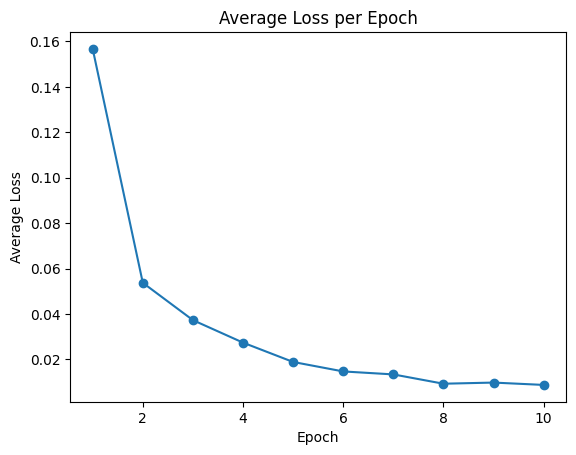

In [17]:
plt.plot(range(1, 11), [loss for loss in losswatch], marker='o')
plt.title('Average Loss per Epoch') 
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.show()  

In [31]:
test_data = pd.read_csv("test.csv")
X = torch.tensor(test_data.values, dtype=torch.float32)  # pixel values

count = len(X)
# print(count)
mean = torch.mean(X)
std = torch.std(X)
X = (X - mean) / std
X = X.view(count, 1, 28, 28)
   

model.eval()  # Set the model to evaluation mode
with torch.no_grad():  # Disable gradient calculation   
    output = model(X    )  # Get the model's predictions
    predicted_labels = torch.argmax(output, dim=1)  # Get the predicted class labels


Predicted label for the 99th test image: 4


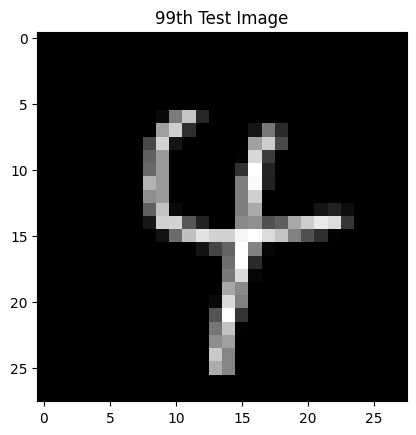

In [34]:
index = 99
plt.imshow(X[index].squeeze(), cmap='gray')
plt.title(f'{index}th Test Image') 
print(f"Predicted label for the {index}th test image: {predicted_labels[index].item()}")   